In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping


In [62]:
# Cargar dataset real - cáncer de mama
df = pd.read_csv('../../datos_completos_limpios.csv')
mediana_brecha = df['Brecha'].median()
df['Brecha_categoria'] = (df['Brecha'] > mediana_brecha).astype(int)

feature_columns = ['DEPARTAMENTO', 'PROVINCIA', 'AÑO', 
                   'Población_Total', 'Hombres', 'Mujeres', 
                   'Tasa_Hombres', 'Tasa_Mujeres']

X = df[feature_columns].copy()
y = df['Brecha_categoria'].copy() 

In [63]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


numeric_features = ['AÑO', 'Población_Total', 'Hombres', 'Mujeres', 
                    'Tasa_Hombres', 'Tasa_Mujeres']
categorical_features = ['DEPARTAMENTO', 'PROVINCIA']

numeric_transformer = StandardScaler() 
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [65]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [66]:
# Crear modelo secuencial de red neuronal simple
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Salida binaria


/home/kaereyes/Documentos/Universidad/Machine Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model = Sequential()
model.add(Dense(32, input_dim=X_train_processed.shape[1], activation='relu'))
model.add(Dropout(0.3))  # Regularización
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # <-- IGUAL: salida binaria

In [68]:
# Compilar modelo con función de pérdida y métrica
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Entrenar modelo guardando la historia para graficar
history = model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8080 - loss: 0.4258 - val_accuracy: 0.9257 - val_loss: 0.1956
Epoch 2/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9260 - loss: 0.2081 - val_accuracy: 0.9600 - val_loss: 0.1272
Epoch 3/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9424 - loss: 0.1545 - val_accuracy: 0.9697 - val_loss: 0.0963
Epoch 4/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9564 - loss: 0.1262 - val_accuracy: 0.9730 - val_loss: 0.0807
Epoch 5/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9630 - loss: 0.1031 - val_accuracy: 0.9730 - val_loss: 0.0744
Epoch 6/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9654 - loss: 0.0955 - val_accuracy: 0.9786 - val_loss: 0.0611
Epoch 7/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9717 - loss: 0.0810 - val_accuracy: 0.9782 - val_loss: 0.0819
Epoch 8/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9714 - loss: 0.0796 - val_accuracy: 0.9810

In [70]:
# Evaluar en conjunto de prueba
y_pred_prob = model.predict(X_test_processed).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy en test:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Brecha Baja', 'Brecha Alta']))

166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy en test: 0.9911471086833679
              precision    recall  f1-score   support

 Brecha Baja       0.99      0.99      0.99      2671
 Brecha Alta       0.99      0.99      0.99      2638

    accuracy                           0.99      5309
   macro avg       0.99      0.99      0.99      5309
weighted avg       0.99      0.99      0.99      5309



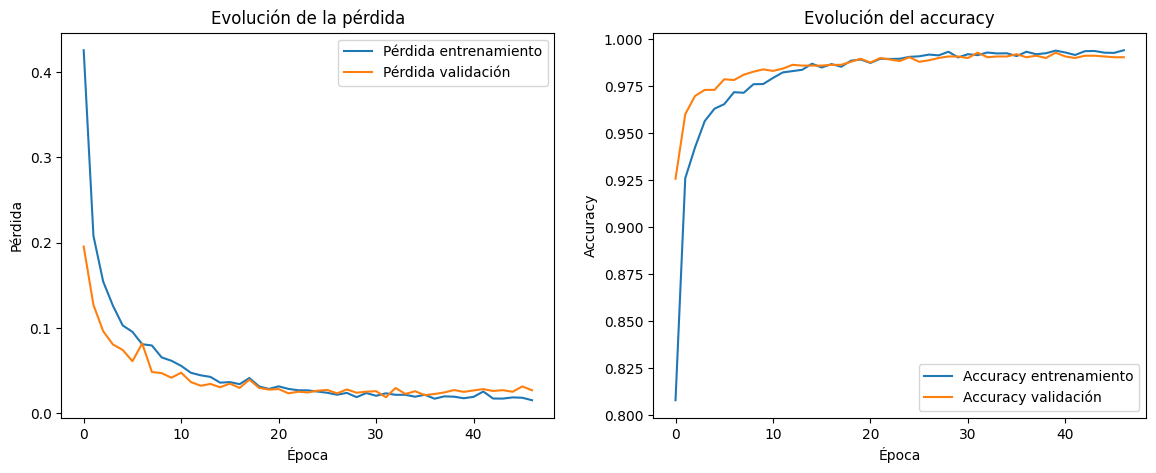

In [71]:

# Graficar pérdidas y accuracies durante entrenamiento
plt.figure(figsize=(14,5))

# Gráfico de pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Gráfico de accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución del accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
